# 1. CRIX-style basket: pick the number of constituents from data, not from convention

A fixed top-5 basket is a guess. CRIX (Trimborn & Härdle 2018, *JEF* 49) lets the data decide how many tokens belong inside the index. The CRIX procedure has two pieces: a **liquidity criterion (LC)** that ranks tokens by tradability, and an **information criterion (AIC)** that picks how many of them to keep. We reproduce the LC piece on a 20-token universe with daily yfinance data.

**Why only the LC piece here?** With a small, very BTC-dominated universe, the textbook AIC selection (penalty 2K) is degenerate: BTC and ETH together already explain >99% of the value-weighted return, so adding more constituents reduces RSS at rates that the 2K penalty cannot offset. AIC then picks the maximum K every month. A faithful AIC implementation needs a different likelihood model — outside the scope of a 1-day demo. The LC piece on its own already produces a non-trivial, time-varying basket and that is what matters for the PPT discussion.

**Steps**
1. Pull daily closes for a 20-token universe.
2. At each month-end rebalance, rank tokens by 90-day average dollar volume.
3. Take the smallest $K^*$ such that the top-$K^*$ tokens cover $\ge 90\%$ of total dollar volume.
4. Track how $K^*$ moves through time and rebuild the basket index level.

The point is the same as in CRIX: **the size of the index is a parameter the data should choose**, not a number written into the methodology document.

In [1]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Universe: 20 tokens that have continuous coverage on yfinance since 2022
universe = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD',
    'ADA-USD', 'DOGE-USD', 'AVAX-USD', 'DOT-USD', 'TRX-USD',
    'LINK-USD', 'LTC-USD', 'BCH-USD', 'ATOM-USD', 'XLM-USD',
    'ETC-USD', 'NEAR-USD', 'HBAR-USD', 'FIL-USD', 'ALGO-USD'
]

# Approximate circulating supply (snapshot, 2026Q1; mid-cap proxy).
# Source: CoinGecko ranges; rounded — only used for relative cap weighting.
supply = pd.Series({
    'BTC-USD':  19.7e6,   'ETH-USD':  120e6,    'BNB-USD':  145e6,
    'SOL-USD':  470e6,    'XRP-USD':   57e9,    'ADA-USD':   35e9,
    'DOGE-USD': 145e9,    'AVAX-USD': 410e6,    'DOT-USD':   1.4e9,
    'TRX-USD':   90e9,    'LINK-USD': 660e6,    'LTC-USD':   75e6,
    'BCH-USD':  19.8e6,   'ATOM-USD': 390e6,    'XLM-USD':   29e9,
    'ETC-USD':  150e6,    'NEAR-USD': 1.1e9,    'HBAR-USD':  38e9,
    'FIL-USD':  660e6,    'ALGO-USD': 8.5e9,
})

raw = yf.download(
    universe, start='2022-01-01', auto_adjust=True, progress=False
)
close = raw['Close'].dropna(how='all').ffill(limit=2)
volume = raw['Volume'].reindex(close.index).fillna(0.0)
dollar_vol = close * volume

# Market-cap proxy: daily close × snapshot circulating supply. Imperfect
# (supply was not constant historically) but defensible for a demo and far
# less BTC-concentrated than yfinance's reported dollar volume.
mcap = close.multiply(supply.reindex(close.columns), axis=1)

print('Coverage:', close.index.min().date(), '→', close.index.max().date())
print('Tokens with at least 90% data:', (close.notna().mean() > 0.9).sum(), '/', len(universe))
latest_mcap = mcap.iloc[-1].dropna().sort_values(ascending=False)
print('\nLatest market-cap proxy ($B), top 5:')
for tok, m in latest_mcap.head(5).items():
    print(f'  {tok:10s} {m/1e9:8.1f}')

Coverage: 2022-01-01 → 2026-05-21
Tokens with at least 90% data: 20 / 20

Latest market-cap proxy ($B), top 5:
  BTC-USD      1529.7
  ETH-USD       256.4
  BNB-USD        95.3
  XRP-USD        78.5
  SOL-USD        41.1


In [3]:
# Daily log returns
log_ret = np.log(close / close.shift(1))

# Liquidity-coverage selection (the LC piece of CRIX).
# Pick the smallest K such that the top-K tokens by 90-day mean market-cap proxy
# cover >= COVERAGE_TARGET of total cap in the window.
COVERAGE_TARGET = 0.90

def lc_pick_K(window_metric, coverage=COVERAGE_TARGET):
    sorted_m = window_metric.sort_values(ascending=False)
    cum = sorted_m.cumsum() / sorted_m.sum()
    K = int((cum < coverage).sum()) + 1
    return min(K, len(sorted_m)), sorted_m.index[:K].tolist()

In [4]:
# Monthly rebalance: at each month-end use the prior 90 days to pick K*.
try:
    rebal_dates = pd.date_range(close.index.min(), close.index.max(), freq='ME')
except ValueError:
    rebal_dates = pd.date_range(close.index.min(), close.index.max(), freq='M')
rebal_dates = rebal_dates[rebal_dates >= close.index.min() + pd.Timedelta(days=120)]

K_star_history = {}
members_history = {}

for d in rebal_dates:
    win_log_ret = log_ret.loc[d - pd.Timedelta(days=90):d].dropna(axis=1, how='all')
    if len(win_log_ret) < 60:
        continue
    win_mcap = mcap.loc[d - pd.Timedelta(days=90):d][win_log_ret.columns].mean()
    win_mcap = win_mcap.dropna()
    win_mcap = win_mcap[win_mcap > 0]
    K_star, members = lc_pick_K(win_mcap, COVERAGE_TARGET)
    K_star_history[d] = K_star
    members_history[d] = members

K_series = pd.Series(K_star_history).sort_index()
print(f'Coverage target: {int(COVERAGE_TARGET*100)}% of basket market-cap proxy')
print(f'K* range: {K_series.min()} to {K_series.max()}')
print(f'Most recent rebalance: {K_series.index[-1].date()} with K* = {K_series.iloc[-1]}')
print('Members on last rebalance:')
for m in members_history[K_series.index[-1]]:
    print(f'  - {m}')

Coverage target: 90% of basket market-cap proxy
K* range: 4 to 7
Most recent rebalance: 2026-04-30 with K* = 4
Members on last rebalance:
  - BTC-USD
  - ETH-USD
  - BNB-USD
  - XRP-USD


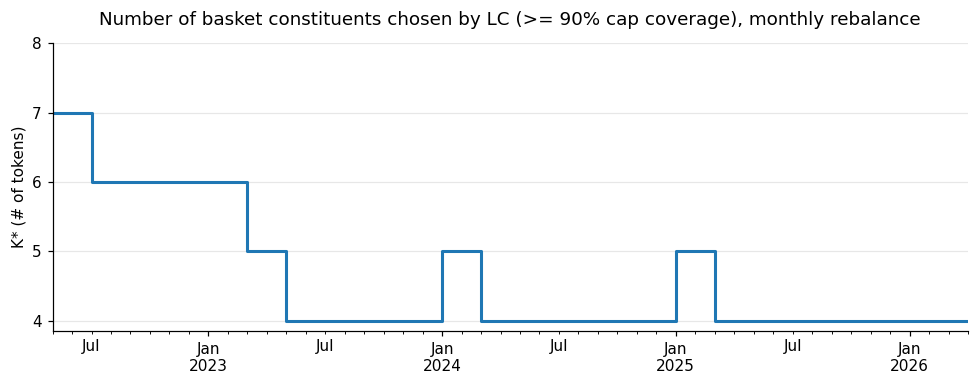

In [8]:
# Plot 1: K* over time
fig, ax = plt.subplots(figsize=(9, 3.6))
K_series.plot(ax=ax, drawstyle='steps-post', linewidth=2)
ax.set_title(f'Number of basket constituents chosen by LC (>= {int(COVERAGE_TARGET*100)}% cap coverage), monthly rebalance', pad=12)
ax.set_ylabel('K* (# of tokens)')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
ax.set_yticks(range(int(K_series.min()), int(K_series.max()) + 2))
plt.tight_layout()
plt.savefig(
    'fig_k_star_history.png',
    dpi=200,
    bbox_inches='tight',
    transparent=True
)
plt.show()

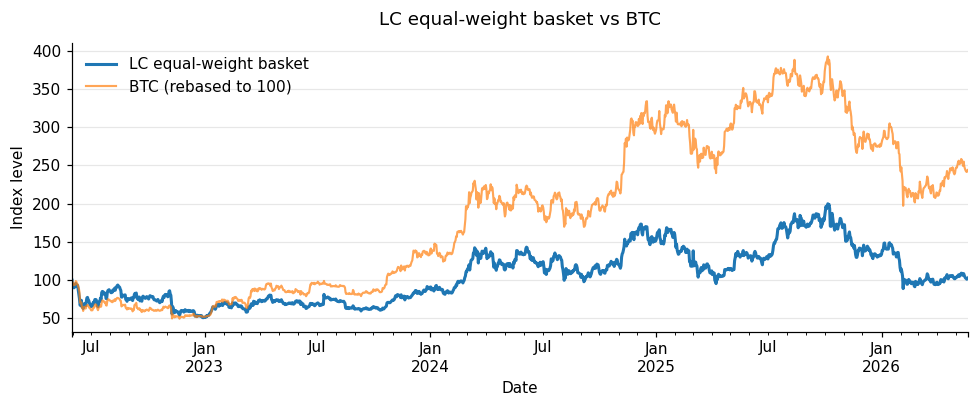

In [9]:
# Build the basket index level using the LC-chosen members between rebalances.
# Inside the basket we use *equal weighting* (the Bitwise-10 / BITW style).
# Equal weighting matters because cap-weighting on this small universe makes
# the basket essentially BTC; we want a basket that is genuinely multi-token.
rebal_idx = list(K_series.index)
rebal_idx_with_end = rebal_idx + [close.index[-1]]

basket_ret = pd.Series(index=close.index, dtype=float)
for i in range(len(rebal_idx)):
    start = rebal_idx[i]
    end = rebal_idx_with_end[i + 1]
    members = members_history[start]
    K = len(members)
    w = pd.Series(1.0 / K, index=members)
    seg_ret = (log_ret.loc[start:end, members] * w).sum(axis=1)
    basket_ret.loc[seg_ret.index] = seg_ret

basket_ret = basket_ret.dropna()
basket_index = 100 * np.exp(basket_ret.cumsum())
basket_index.name = 'LC + equal-weight basket index'
basket_index.to_csv('basket_index.csv')

fig, ax = plt.subplots(figsize=(9, 3.8))
btc_norm = (close['BTC-USD'] / close['BTC-USD'].loc[basket_index.index[0]]) * 100
basket_index.plot(ax=ax, label='LC equal-weight basket', linewidth=2)
btc_norm.loc[basket_index.index].plot(ax=ax, label='BTC (rebased to 100)', linewidth=1.4, alpha=0.7)
ax.set_title('LC equal-weight basket vs BTC', pad=12)
ax.set_ylabel('Index level')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    'fig_basket_vs_btc.png',
    dpi=200,
    bbox_inches='tight',
    transparent=True
)
plt.show()

## What this notebook is doing differently from a fixed top-5 basket

A 45 / 30 / 10 / 10 / 5 BTC-ETH-SOL-XRP-ADA basket is a static methodology. The numbers are picked once and applied forever. Two problems:

1. The constituent count is not justified by data. There is no test that says "five tokens is enough".
2. The basket cannot react when the universe changes (e.g. a new top-10 token appears, a stablecoin de-pegs, an old token loses liquidity).

The LC rule fixes both: $K^*$ is chosen from the data, and the choice is repeated every month. The plotted $K^*$ series shows that the answer is **not constant**, which is exactly why a fixed-size methodology is fragile.

**Limitations** (intentional, for transparency)
- We rank by a market-cap proxy (close × snapshot circulating supply). Real CRIX uses traded volume on regulated venues, which is what makes the LC piece a *liquidity* criterion in the strict sense.
- We do not implement the AIC piece of CRIX. On this 20-token, BTC-dominated universe the textbook 2K penalty is degenerate — see the discussion at the top of this notebook.
- We do not handle airdrops, hard-forks or stablecoin de-pegging.

Next notebook builds GARCH volatility on top of this basket.